In [107]:
%matplotlib widget
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd


In [108]:
df = pd.read_csv('/Users/mrvarshney/Codes/ARIES/star_files_3_dat/Final_1731_Photometry.dat', delimiter = '\t')
time = df['JD']
flux = 10**(-0.4 * df['Differential_Magnitude'])
flux_err = 10**(-0.4 * df['Differential_Error'])

lc = lk.LightCurve(time = time, flux = flux, flux_err=0.05).normalize()

(0.5, 1.5)

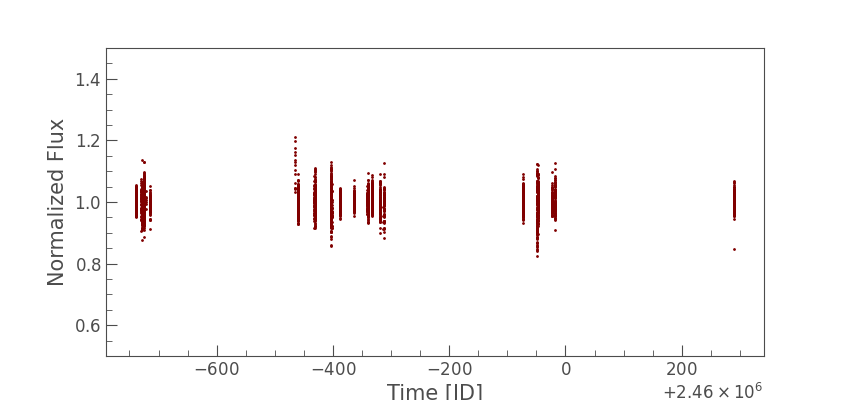

In [109]:
lc.plot(color = 'maroon', marker = '.', lw = 0)
plt.ylim(0.5,1.5)

<Axes: xlabel='Frequency [$\\mathrm{\\frac{1}{d}}$]', ylabel='Power'>

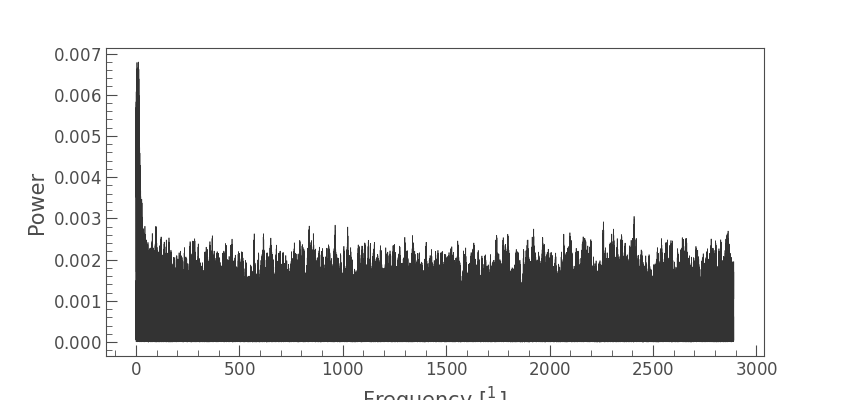

In [110]:
pg = lc.to_periodogram()
pg.plot()

In [111]:
pg.show_properties()

lightkurve.Periodogram properties:
      Attribute           Description     Units
---------------------- ------------------ -----
                nterms                  1      
          default_view          frequency      
             ls_method               fast      
frequency_at_max_power            11.2857 1 / d
             max_power             0.0068      
               nyquist          2890.1709 1 / d
   period_at_max_power             0.0886     d
             frequency  array (14860685,) 1 / d
                period  array (14860685,)     d
                 power  array (14860685,)      
                 label <class 'NoneType'>      
                  meta     <class 'dict'>      
              targetid <class 'NoneType'>      


In [112]:
best_period = pg.period_at_max_power
print(best_period)

0.08860744808628038 d


<Axes: xlabel='Phase (Normalized)', ylabel='Normalized Flux'>

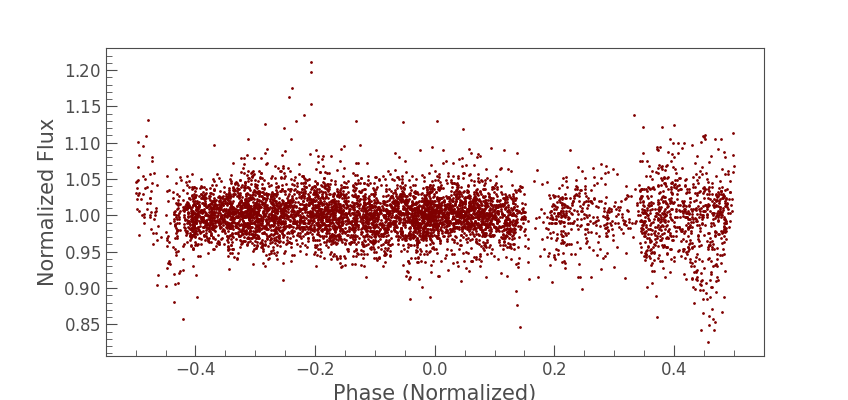

In [117]:
import astropy.units as u

epoch_time = (2.46e6 - 450) * u.day
lc_phased = lc.fold(0.549, normalize_phase=True)
lc_phased.plot(linewidth =0, color = 'maroon', marker = '.')

Text(0.5, 1.0, 'Period: 0.08860744808628038 d')

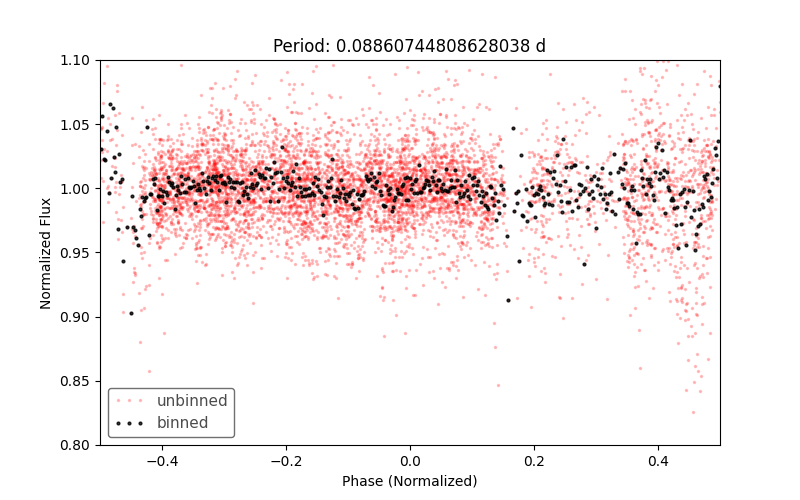

In [118]:
lc_phased_binned = lc_phased.bin(3/60/24)
fig, ax = plt.subplots(figsize = (8,5))

lc_phased.plot(ax = ax, marker = '.', linewidth = 0, color = 'red', alpha = 0.2, markersize = 3, label = 'unbinned')
lc_phased_binned.plot(
    ax=ax,
    linestyle='',          # do NOT connect points
    marker='o',
    color='black',
    markersize=2,
    alpha=0.8,
    label='binned',
)

# set x and y axis limits (for different targets these limits will be different!)
plt.xlim(-0.5,0.5)
plt.ylim(0.8,1.1)
plt.title(f"Period: {best_period}")
